In [3]:

exec(open(f"_run_.py", encoding="utf-8").read())




[*********************100%***********************]  10 of 10 completed

1508 this is the length of my data 
This is the first test to take our project into production
df_prices shape: (1508, 10)
PRICES SHAPE: (1508, 10)
                   UNH       TSLA         JPM       AAPL      NVDA      GOOGL  \
Date                                                                            
2020-01-02  263.196899  28.684000  119.036415  72.400520  5.970754  67.873032   
2020-01-03  260.533478  29.534000  117.465576  71.696640  5.875186  67.517975   
2020-01-06  262.342072  30.102667  117.372185  72.267914  5.899825  69.317581   
2020-01-07  260.758423  31.270666  115.376762  71.928055  5.971251  69.183708   
2020-01-08  266.256287  32.809334  116.276817  73.085106  5.982450  69.676125   

                  META           V       AMZN        MSFT  
Date                                                       
2020-01-02  208.146591  182.809250  94.900497  152.158417  
2020-01-03  207.045227  181.355408  93.748497  150.263748  
2020-01-06  210.944611  180.963181  95.14399

# Fix Data set 

In [4]:
df_returns = df_returns.dropna()


# check 

In [29]:
print(df_returns.shape)
print(df_returns.isna().sum().sum())

(1507, 10)
0


In [30]:
# Flip df 
X = df_returns.T

print(X.shape)

(10, 1507)


In [31]:
df_returns

,TSLA,META,AMZN,GOOGL,MSFT,JPM,AAPL,UNH,V,NVDA
Date,,,,,,,,,,
2020-01-03,0.029633,-0.005291,-0.012139,-0.005231,-0.012452,-0.013196,-0.009722,-0.010120,-0.007953,-0.016006
2020-01-06,0.019255,0.018833,0.014886,0.026654,0.002585,-0.000795,0.007968,0.006942,-0.002162,0.004194
2020-01-07,0.038801,0.002164,0.002092,-0.001932,-0.009118,-0.017001,-0.004703,-0.006036,-0.002643,0.012107
2020-01-08,0.049205,0.010138,-0.007809,0.007118,0.015928,0.007801,0.016086,0.021084,0.017118,0.001875
2020-01-09,-0.021945,0.014311,0.004799,0.010498,0.012493,0.003651,0.021241,-0.005677,0.006930,0.010983
...,...,...,...,...,...,...,...,...,...,...
2025-12-24,-0.000330,0.003925,0.001034,-0.000827,0.002403,0.009941,0.005324,0.008559,0.004980,-0.003171
2025-12-26,-0.021034,-0.006382,0.000602,-0.001847,-0.000635,-0.003828,-0.001497,0.012974,-0.000394,0.010180
2025-12-29,-0.032724,-0.006935,-0.001935,0.000159,-0.001251,-0.012686,0.001317,-0.008709,-0.001099,-0.012124


### very important here , Transpose the df -> PREPROCESS DATA

In [32]:
# transpose 
X = df_returns.T

# scale -> normalize data 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape) # expect (low # , high #) 

(10, 1507)


# PCA analysis 

In [37]:
pca_full = PCA()
pca_full.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [39]:
explained = pca_full.explained_variance_ratio_.round(6)

print(explained)

[0.303026 0.203851 0.124499 0.089307 0.077927 0.065449 0.053785 0.047838
 0.034318 0.      ]


In [43]:
cum_var = np.cumsum(explained).round(6)*100 

print(cum_var)

[ 30.3026  50.6877  63.1376  72.0683  79.861   86.4059  91.7844  96.5682
 100.     100.    ]


In [44]:
for i in range(1, 11):
    print(f"{i} components → {cum_var[i-1]:.4f}")

1 components → 30.3026
2 components → 50.6877
3 components → 63.1376
4 components → 72.0683
5 components → 79.8610
6 components → 86.4059
7 components → 91.7844
8 components → 96.5682
9 components → 100.0000
10 components → 100.0000


In [ ]:
# PCA do not have context 
# variables do or keep variables 



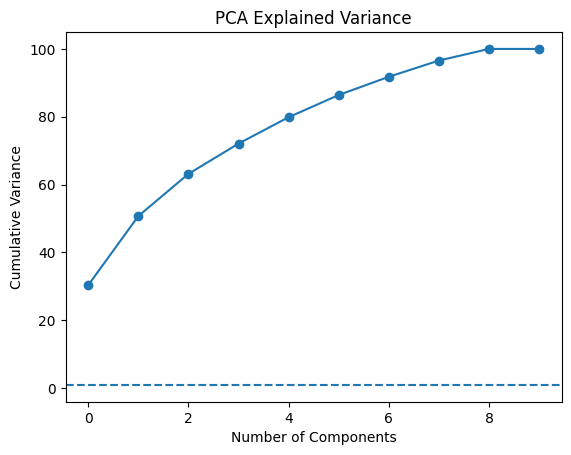

In [45]:
import matplotlib.pyplot as plt

plt.plot(cum_var, marker='o')
plt.axhline(0.9, linestyle='--')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("PCA Explained Variance")
plt.show()

In [50]:
n_comp = 3   # adjust if you decided 4 or 5

pca = PCA(n_components=n_comp)
X_pca = pca.fit_transform(X_scaled)

In [51]:
df_pca = pd.DataFrame(
    X_pca,
    index=X.index,   # stock names
    columns=[f'PC{i+1}' for i in range(n_comp)]
)

print(df_pca)

             PC1        PC2        PC3
TSLA  -57.023812  23.444713  -1.162745
META    2.652176 -12.977906  21.625575
AMZN   -0.207352  -8.060109  16.205040
GOOGL   5.018570  -3.315918  11.916420
MSFT    5.735856  -4.672273   3.583502
JPM    15.482595  15.232594 -10.488246
AAPL    4.477942   1.265115   1.943124
UNH    23.603570  19.838898 -15.496940
V      14.840645   8.664150  -3.102154
NVDA  -14.580191 -39.419263 -25.023576


In [54]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

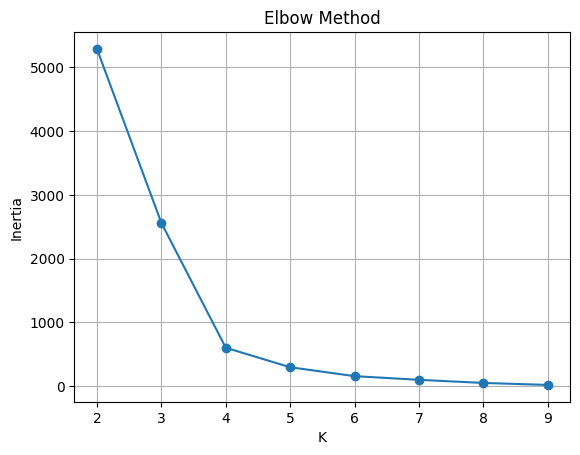

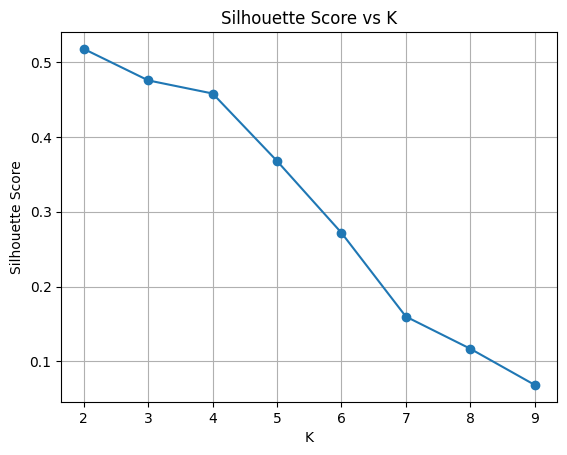

In [55]:
X = df_pca[['PC1','PC2','PC3']]

inertia = []
sil = []

K_range = range(2,10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    
    inertia.append(kmeans.inertia_)
    sil.append(silhouette_score(X, labels))

pd.DataFrame({'k':K_range, 'inertia':inertia, 'silhouette':sil})

import matplotlib.pyplot as plt

# -----------------------------
# ELBOW (INERTIA)
# -----------------------------
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid()
plt.show()


# -----------------------------
# SILHOUETTE
# -----------------------------
plt.figure()
plt.plot(K_range, sil, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')
plt.grid()
plt.show()

# cluster analysis 

# EASY EXAMPLE

In [10]:
# # --------------------------------------------------
# # 📦 IMPORTS
# # --------------------------------------------------
# import yfinance as yf
# import pandas as pd

# # --------------------------------------------------
# # 📊 STOCKS SELECTED
# # --------------------------------------------------
# tickers = [
#     "AAPL",  # Apple
#     "MSFT",  # Microsoft
#     "NVDA",  # Nvidia
#     "AMZN",  # Amazon
#     "GOOGL", # Alphabet
#     "TSLA",  # Tesla
#     "META",  # Meta
#     "JPM",   # JPMorgan
#     "V",     # Visa
#     "UNH"    # UnitedHealth
# ]

# # --------------------------------------------------
# # 📥 DOWNLOAD DATA (yfinance)
# # Variables:
# # Open, High, Low, Close, Adj Close, Volume
# # --------------------------------------------------
# df = yf.download(
#     tickers,
#     start="2020-01-01",
#     end="2026-01-01",
#     group_by="ticker",
#     auto_adjust=False
# )

# # --------------------------------------------------
# # 🔧 FLATTEN MULTI-INDEX COLUMNS
# # --------------------------------------------------
# df.columns = [f"{col[0]}_{col[1]}" for col in df.columns]

# # --------------------------------------------------
# # 📅 RESET INDEX (Date → column)
# # --------------------------------------------------
# df = df.reset_index()

# # --------------------------------------------------
# # 🎯 SELECT CORE VARIABLE (Adj Close)
# # --------------------------------------------------
# df_prices = df.filter(like='Adj Close')
# df_prices.columns = [col.replace('_Adj Close','') for col in df_prices.columns]

# # --------------------------------------------------
# # 📈 RETURNS (FOR MODELING)
# # --------------------------------------------------
# df_returns = df_prices.pct_change().dropna()

# # --------------------------------------------------
# # 📊 FINAL OUTPUTS
# # --------------------------------------------------
# print("STOCKS:", tickers)
# print("\nVARIABLES DOWNLOADED:", ['Open','High','Low','Close','Adj Close','Volume'])
# print("\nDF SHAPE:", df.shape)
# print("RETURNS SHAPE:", df_returns.shape)

# # df         → full raw dataset
# # df_prices  → clean price matrix
# # df_returns → ready for ML / PCA / clustering

[*********************100%***********************]  10 of 10 completed

STOCKS: ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL', 'TSLA', 'META', 'JPM', 'V', 'UNH']

VARIABLES DOWNLOADED: ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

DF SHAPE: (1508, 61)
RETURNS SHAPE: (1507, 10)


In [11]:
df

,Date,TSLA_Open,TSLA_High,TSLA_Low,TSLA_Close,TSLA_Adj Close,TSLA_Volume,AMZN_Open,AMZN_High,AMZN_Low,...,UNH_Low,UNH_Close,UNH_Adj Close,UNH_Volume,NVDA_Open,NVDA_High,NVDA_Low,NVDA_Close,NVDA_Adj Close,NVDA_Volume
0,2020-01-02,28.299999,28.713333,28.114000,28.684000,28.684000,142981500,93.750000,94.900497,93.207497,...,289.790009,292.500000,263.196991,2543400,5.968750,5.997750,5.918000,5.997750,5.970755,237536000
1,2020-01-03,29.366667,30.266666,29.128000,29.534000,29.534000,266677500,93.224998,94.309998,93.224998,...,284.359985,289.540009,260.533417,2711400,5.877500,5.945750,5.852500,5.901750,5.875186,205384000
2,2020-01-06,29.364668,30.104000,29.333332,30.102667,30.102667,151995000,93.000000,95.184502,93.000000,...,287.220001,291.549988,262.342010,3079100,5.808000,5.931750,5.781750,5.926500,5.899825,262636000
3,2020-01-07,30.760000,31.441999,30.224001,31.270666,31.270666,268231500,95.224998,95.694504,94.601997,...,287.579987,289.790009,260.758423,2492900,5.955000,6.044250,5.909750,5.998250,5.971252,314856000
4,2020-01-08,31.580000,33.232666,31.215334,32.809334,32.809334,467164500,94.902000,95.550003,94.321999,...,290.040009,295.899994,266.256226,3379200,5.994000,6.051000,5.953750,6.009500,5.982451,277108000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1503,2025-12-24,488.480011,490.899994,476.799988,485.399994,485.399994,41285400,232.130005,232.949997,231.330002,...,324.130005,327.579987,325.052917,2842700,187.940002,188.910004,186.589996,188.610001,188.599792,65528500
1504,2025-12-26,485.230011,489.089996,473.820007,475.190002,475.190002,58780700,232.039993,232.990005,231.179993,...,326.260010,331.829987,329.270142,4359300,189.919998,192.690002,188.000000,190.529999,190.519684,139740300
1505,2025-12-29,469.000000,469.399994,459.000000,459.640015,459.640015,66263000,231.940002,232.600006,230.770004,...,328.279999,328.940002,326.402435,4346800,187.710007,188.759995,185.910004,188.220001,188.209808,120006100
1506,2025-12-30,461.089996,463.119995,453.829987,454.429993,454.429993,59238500,231.210007,232.770004,230.199997,...,329.510010,332.160004,329.597626,4432500,188.240005,188.990005,186.929993,187.539993,187.529846,97687300
